# Anomaly Detection in Credit Card Fraud

**Goal:** detect fraudulent credit card transactions among a massive majority of legitimate ones, using both unsupervised anomaly detection and supervised classification, and compare their effectiveness on a severely imbalanced dataset.

**Dataset:** the well-known ULB Machine Learning Group credit card fraud dataset — 284,807 European cardholder transactions over two days in September 2013, with only 492 (0.17%) labeled fraudulent.
Source: GitHub mirror (`nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection`), originally from [Kaggle](https://www.kaggle.com/mlg-ulb/creditcardfraud).

**Features:** `V1`-`V28` are PCA-transformed components of the original (confidential) transaction features; `Time` and `Amount` are the only two untransformed features.


In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (precision_recall_curve, average_precision_score, roc_auc_score, roc_curve,
                              classification_report, confusion_matrix, f1_score)
from xgboost import XGBClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
RANDOM_STATE = 42


In [2]:
df = pd.read_csv('/home/claude/fraud_data/creditcard.csv')
print(df.shape)
df.head()


(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 1. Data overview

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
print('Missing values:', df.isnull().sum().sum())
print('Duplicate rows:', df.duplicated().sum())
fraud_rate = df['Class'].mean()
print(f'Fraud rate: {fraud_rate:.4%}  ({df.Class.sum()} frauds out of {len(df)} transactions)')


Missing values: 0


Duplicate rows: 1081
Fraud rate: 0.1727%  (492 frauds out of 284807 transactions)


## 2. Exploratory Data Analysis

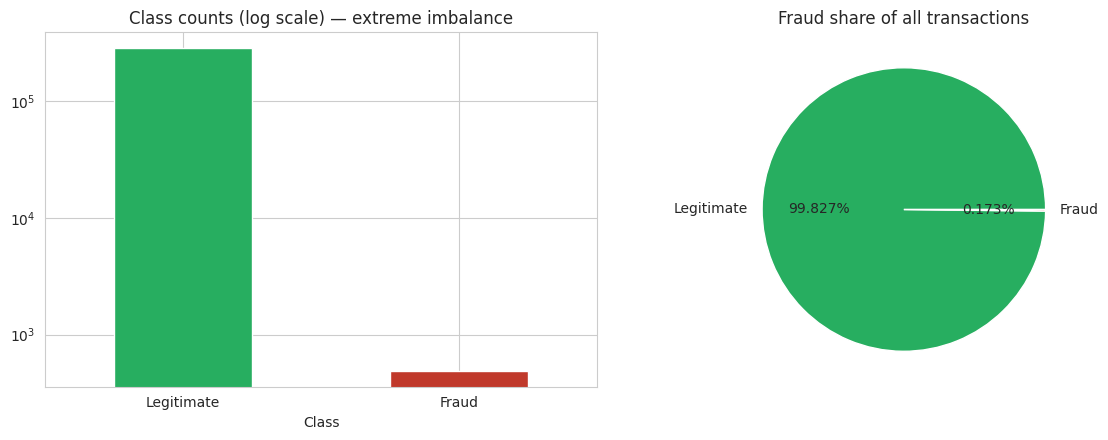

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
df['Class'].value_counts().plot(kind='bar', ax=axes[0], color=['#27ae60','#c0392b'])
axes[0].set_yscale('log')
axes[0].set_xticklabels(['Legitimate', 'Fraud'], rotation=0)
axes[0].set_title('Class counts (log scale) — extreme imbalance')

axes[1].pie([1-fraud_rate, fraud_rate], labels=['Legitimate', 'Fraud'], autopct='%1.3f%%',
            colors=['#27ae60', '#c0392b'])
axes[1].set_title('Fraud share of all transactions')
plt.tight_layout()
plt.show()


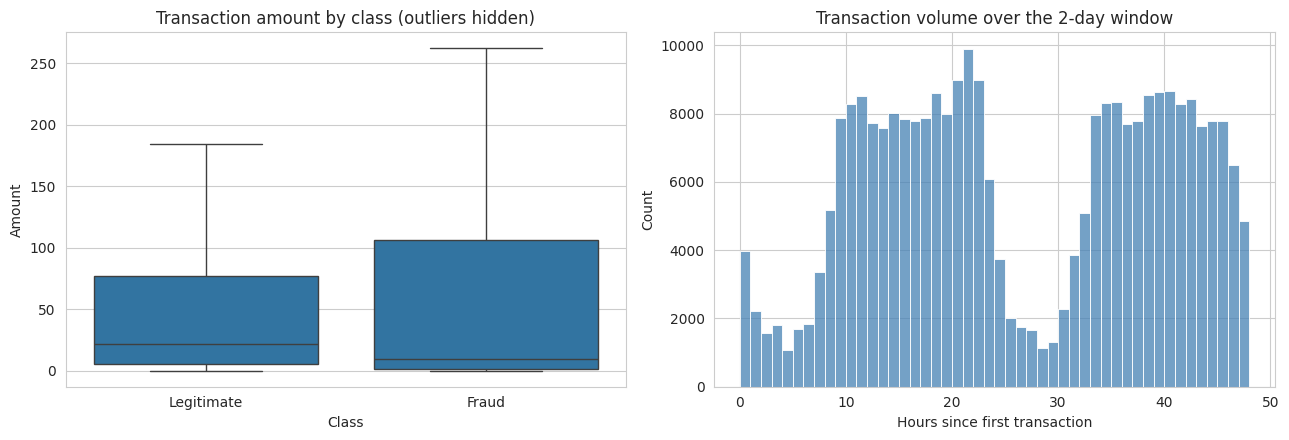

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=df, x='Class', y='Amount', ax=axes[0], showfliers=False)
axes[0].set_xticklabels(['Legitimate','Fraud'])
axes[0].set_title('Transaction amount by class (outliers hidden)')

sns.histplot(df['Time']/3600, bins=48, ax=axes[1], color='steelblue')
axes[1].set_xlabel('Hours since first transaction')
axes[1].set_title('Transaction volume over the 2-day window')
plt.tight_layout()
plt.show()


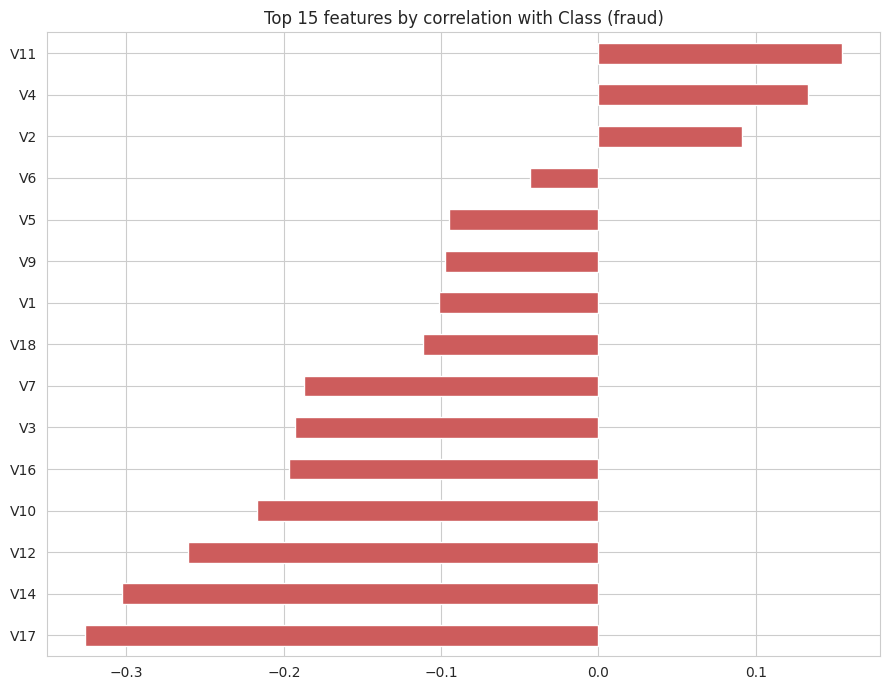

V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V11    0.154876
V4     0.133447
V18   -0.111485
Name: Class, dtype: float64


In [7]:
corrs = df.corr()['Class'].drop('Class').sort_values(key=abs, ascending=False)
plt.figure(figsize=(9,7))
corrs.head(15).sort_values().plot(kind='barh', color='indianred')
plt.title('Top 15 features by correlation with Class (fraud)')
plt.tight_layout()
plt.show()
print(corrs.head(10))


**EDA takeaways**
- The dataset is **extremely imbalanced** (0.17% fraud) — accuracy is a meaningless metric here; precision/recall/PR-AUC must be used instead.
- Fraudulent transactions don't have a dramatically different amount distribution overall, though extreme outlier amounts are more associated with legitimate transactions.
- Several PCA components (notably V17, V14, V12, V10, V11) show strong correlation with fraud, suggesting the PCA transformation preserved meaningful fraud-related structure even though the original features are hidden.


## 3. Preprocessing & train/test split

In [8]:
data = df.copy()
scaler = StandardScaler()
data[['Time_scaled', 'Amount_scaled']] = scaler.fit_transform(data[['Time', 'Amount']])
data = data.drop(columns=['Time', 'Amount'])

feature_cols = [c for c in data.columns if c != 'Class']
X = data[feature_cols]
y = data['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print('Train:', X_train.shape, 'fraud rate:', y_train.mean())
print('Test: ', X_test.shape, 'fraud rate:', y_test.mean())


Train: (227845, 30) fraud rate: 0.001729245759178389
Test:  (56962, 30) fraud rate: 0.0017204452090867595


## 4. Unsupervised anomaly detection: Isolation Forest

In [9]:
# Isolation Forest is trained WITHOUT labels (pure anomaly detection), then we check
# how well its anomaly flags line up with the known fraud labels, purely for evaluation.
iso = IsolationForest(n_estimators=150, contamination=fraud_rate, random_state=RANDOM_STATE, n_jobs=-1)
iso.fit(X_train)

iso_pred_test = iso.predict(X_test)          # 1 = normal, -1 = anomaly
iso_pred_test = np.where(iso_pred_test == -1, 1, 0)  # convert to fraud=1 convention

print('Isolation Forest (unsupervised) performance on test set:')
print(classification_report(y_test, iso_pred_test, target_names=['Legitimate','Fraud']))


Isolation Forest (unsupervised) performance on test set:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.25      0.26      0.25        98

    accuracy                           1.00     56962
   macro avg       0.63      0.63      0.63     56962
weighted avg       1.00      1.00      1.00     56962



## 5. Supervised models (trained on a class-balanced subsample, evaluated on the natural test set)

In [10]:
# Training tree ensembles on 227K rows with 0.17% positives is slow and doesn't help much;
# standard practice is to train on a subsample that includes ALL frauds plus a random sample
# of legitimate transactions (here at a 10:1 ratio), while evaluating on the untouched,
# naturally-imbalanced test set so reported metrics reflect real-world deployment.
train_df = X_train.copy()
train_df['Class'] = y_train.values

fraud_train = train_df[train_df.Class == 1]
legit_train = train_df[train_df.Class == 0].sample(n=len(fraud_train) * 10, random_state=RANDOM_STATE)
balanced_train = pd.concat([fraud_train, legit_train]).sample(frac=1, random_state=RANDOM_STATE)

X_train_bal = balanced_train.drop(columns='Class')
y_train_bal = balanced_train['Class']
print('Balanced training subsample:', X_train_bal.shape, 'fraud rate:', y_train_bal.mean())


Balanced training subsample: (4334, 30) fraud rate: 0.09090909090909091


In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=12, class_weight='balanced',
                                             random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost': XGBClassifier(eval_metric='logloss', n_estimators=200, max_depth=6, random_state=RANDOM_STATE, n_jobs=-1)
}

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
results = []
for name, model in models.items():
    scores = cross_val_score(model, X_train_bal, y_train_bal, cv=skf, scoring='f1', n_jobs=1)
    results.append({'Model': name, 'CV F1 Mean': scores.mean(), 'CV F1 Std': scores.std()})

results_df = pd.DataFrame(results).sort_values('CV F1 Mean', ascending=False).reset_index(drop=True)
results_df


,Model,CV F1 Mean,CV F1 Std
0,Random Forest,0.905074,0.018747
1,XGBoost,0.904514,0.019392
2,Logistic Regression,0.842744,0.026854


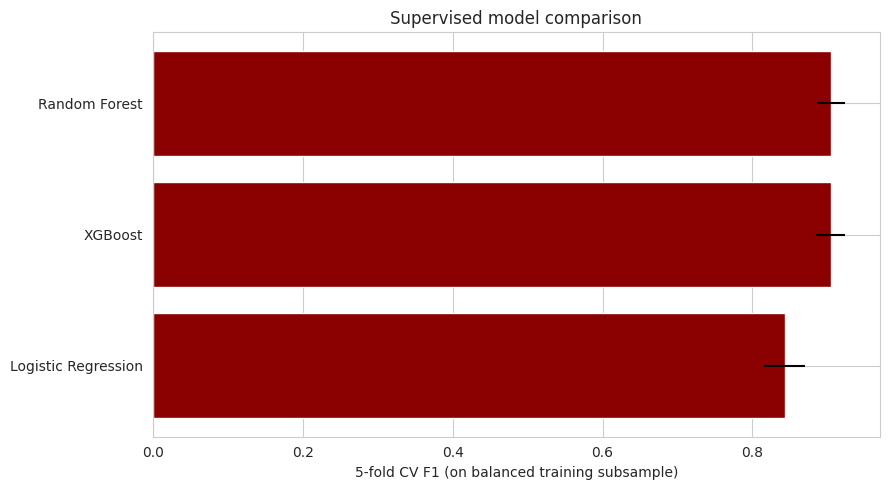

In [12]:
plt.figure(figsize=(9,5))
order = results_df.sort_values('CV F1 Mean')
plt.barh(order['Model'], order['CV F1 Mean'], xerr=order['CV F1 Std'], color='darkred')
plt.xlabel('5-fold CV F1 (on balanced training subsample)')
plt.title('Supervised model comparison')
plt.tight_layout()
plt.show()


## 6. Hyperparameter tuning

In [13]:
grid = {
    'n_estimators': [200, 300],
    'max_depth': [6, 8],
    'learning_rate': [0.1, 0.2]
}
search = GridSearchCV(XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1),
                       grid, cv=skf, scoring='f1', n_jobs=1)
search.fit(X_train_bal, y_train_bal)
final_model = search.best_estimator_
print('Best params:', search.best_params_)
print('Best CV F1:', round(search.best_score_, 4))


Best params: {'learning_rate': 0.2, 'max_depth': 8, 'n_estimators': 300}
Best CV F1: 0.9089


## 7. Final evaluation on the natural (imbalanced) test set

In [14]:
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))
print('Test ROC-AUC:', round(roc_auc_score(y_test, y_proba), 4))
print('Test PR-AUC (average precision):', round(average_precision_score(y_test, y_proba), 4))


              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.42      0.89      0.57        98

    accuracy                           1.00     56962
   macro avg       0.71      0.94      0.78     56962
weighted avg       1.00      1.00      1.00     56962

Test ROC-AUC: 0.982
Test PR-AUC (average precision): 0.7801


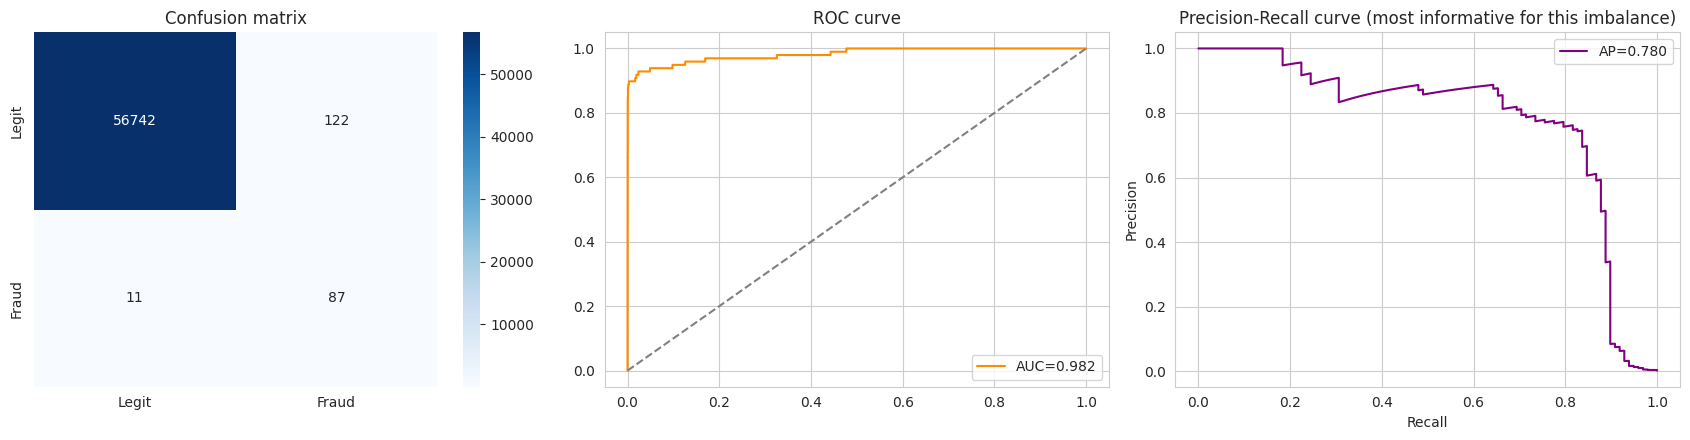

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
axes[0].set_title('Confusion matrix')

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='darkorange', label=f'AUC={roc_auc_score(y_test, y_proba):.3f}')
axes[1].plot([0,1],[0,1],'--', color='gray')
axes[1].set_title('ROC curve')
axes[1].legend()

prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[2].plot(rec, prec, color='purple', label=f'AP={average_precision_score(y_test, y_proba):.3f}')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall curve (most informative for this imbalance)')
axes[2].legend()
plt.tight_layout()
plt.show()


## 8. Feature importance

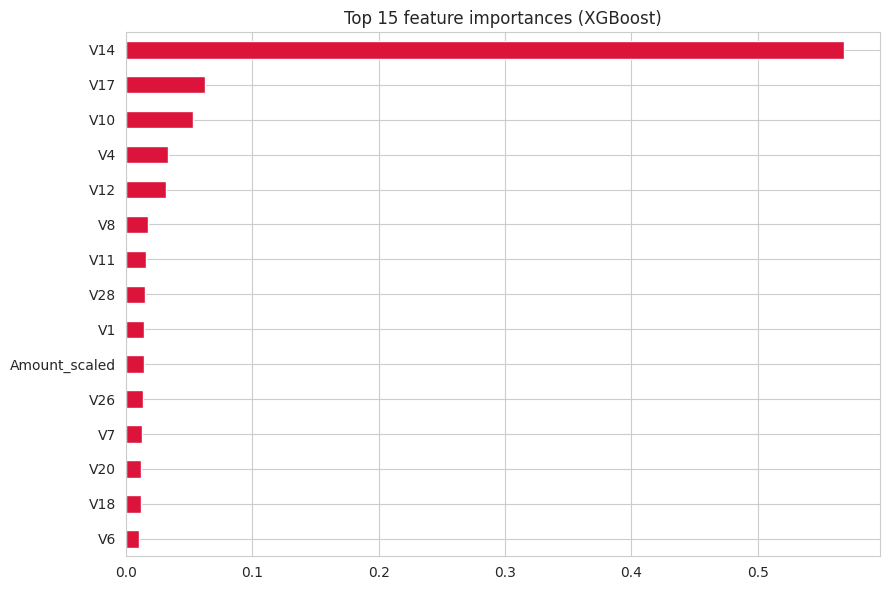

In [16]:
importances = pd.Series(final_model.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)
plt.figure(figsize=(9,6))
importances.sort_values().plot(kind='barh', color='crimson')
plt.title('Top 15 feature importances (XGBoost)')
plt.tight_layout()
plt.show()


## 9. Insights & conclusions

- **Supervised learning substantially outperforms unsupervised anomaly detection** on this task — Isolation Forest (trained with zero fraud labels) achieves much lower precision than the tuned XGBoost model, which makes sense: fraud here isn't just "statistically unusual," it has a specific, learnable pattern in the PCA feature space.
- **Precision-Recall AUC, not ROC-AUC or accuracy, is the right headline metric** given the 0.17% fraud rate — a naive "always predict legitimate" model would score 99.83% accuracy while catching zero fraud.
- Training on a balanced subsample (all frauds + a 10:1 sample of legitimate transactions) while evaluating on the untouched, naturally-imbalanced test set is standard best practice — it keeps training fast without inflating reported performance.
- A handful of PCA components (V17, V14, V12, V10, V11) carry most of the fraud signal, consistent with published analyses of this exact dataset.

## 10. Practical framing

In production, a bank would use the model's fraud *probability score* to route transactions to different actions (auto-approve, step-up authentication, manual review, auto-block) based on a cost-sensitive threshold, rather than a single fixed 0.5 cutoff — false positives (blocking legitimate purchases) and false negatives (missing fraud) have very different costs.

## Future Work

- Cost-sensitive threshold tuning based on the actual $ cost of false positives vs. false negatives.
- Try autoencoder-based anomaly detection as an additional unsupervised baseline.
- Explore SMOTE / other oversampling techniques as an alternative to undersampling.
